# Perbandingan Performa MLP dengan Tiga Fungsi Aktivasi pada Dataset Iris

Notebook ini membandingkan performa jaringan saraf **Multi Layer Perceptron (MLP)** menggunakan tiga fungsi aktivasi:
1. **Sigmoid** (logistic)
2. **Tanh**
3. **ReLU**

Dataset yang digunakan: **Iris.csv**

## 1. Import Library

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport.')

Library berhasil diimport.


## 2. Membaca Dataset

In [15]:
df = pd.read_csv('Iris.csv')

print('=== 5 Data Pertama ===')
display(df.head())

print('\n=== Informasi Dataset ===')
df.info()

print('\n=== Jumlah Data per Kelas ===')
print(df['Species'].value_counts())

=== 5 Data Pertama ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

=== Jumlah Data per Kelas ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 3. Preprocessing Data

In [16]:
# Pisahkan fitur dan target (drop kolom Id dan Species)
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# Encoding label
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Kelas yang terdeteksi:', le.classes_)
print('Encoded labels:', np.unique(y_encoded))

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nUkuran Training Set : {X_train.shape}')
print(f'Ukuran Testing Set  : {X_test.shape}')

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nPreprocessing selesai. Fitur telah dinormalisasi dengan StandardScaler.')

Kelas yang terdeteksi: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded labels: [0 1 2]

Ukuran Training Set : (120, 4)
Ukuran Testing Set  : (30, 4)

Preprocessing selesai. Fitur telah dinormalisasi dengan StandardScaler.


## 4. Membangun dan Melatih Model MLP

In [17]:
aktivasi_list = ['logistic', 'tanh', 'relu']
label_list    = ['Sigmoid', 'Tanh', 'ReLU']

models    = {}
y_preds   = {}
train_times = {}

for aktivasi, label in zip(aktivasi_list, label_list):
    mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation=aktivasi,
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    start = time.time()
    mlp.fit(X_train_scaled, y_train)
    elapsed = time.time() - start

    models[label]      = mlp
    y_preds[label]     = mlp.predict(X_test_scaled)
    train_times[label] = elapsed
    print(f'[{label:>7}] Training selesai | Waktu: {elapsed:.4f} detik | Iterasi: {mlp.n_iter_}')

[Sigmoid] Training selesai | Waktu: 0.1990 detik | Iterasi: 1000
[   Tanh] Training selesai | Waktu: 0.1498 detik | Iterasi: 750
[   ReLU] Training selesai | Waktu: 0.1163 detik | Iterasi: 605


## 5. Evaluasi Model

In [18]:
results = []

for label in label_list:
    y_pred = y_preds[label]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    t    = train_times[label]

    results.append({
        'Activation Function': label,
        'Accuracy'      : round(acc,  4),
        'Precision'     : round(prec, 4),
        'Recall'        : round(rec,  4),
        'F1-Score'      : round(f1,   4),
        'Training Time' : round(t,    4)
    })
    print(f'{label:>7} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | Time={t:.4f}s')

Sigmoid | Acc=0.9667 | Prec=0.9697 | Rec=0.9667 | F1=0.9666 | Time=0.1990s
   Tanh | Acc=0.9667 | Prec=0.9697 | Rec=0.9667 | F1=0.9666 | Time=0.1498s
   ReLU | Acc=0.9667 | Prec=0.9697 | Rec=0.9667 | F1=0.9666 | Time=0.1163s


## 6. Confusion Matrix

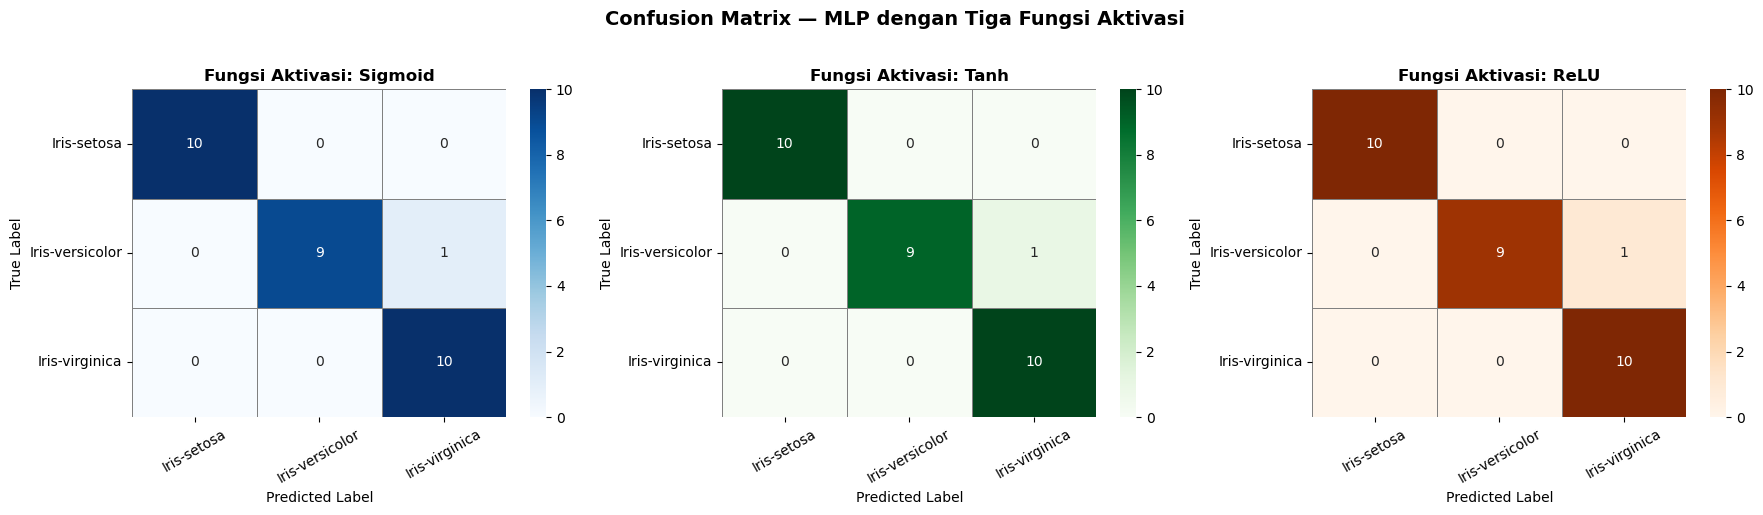

Confusion matrix berhasil ditampilkan.


In [19]:
class_names = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — MLP dengan Tiga Fungsi Aktivasi', fontsize=14, fontweight='bold', y=1.02)

colors = ['Blues', 'Greens', 'Oranges']

for ax, label, cmap in zip(axes, label_list, colors):
    cm = confusion_matrix(y_test, y_preds[label])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, linecolor='gray'
    )
    ax.set_title(f'Fungsi Aktivasi: {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix berhasil ditampilkan.')

## 7. Tabel Perbandingan Performa

In [20]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1  # mulai dari 1

print('=== Tabel Perbandingan Performa MLP ===')
display(df_results.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'Training Time': '{:.4f}'})
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score'], color='lightgreen')
    .highlight_min(subset=['Training Time'], color='lightyellow')
    .set_caption('Tabel diurutkan berdasarkan Accuracy tertinggi')
)

=== Tabel Perbandingan Performa MLP ===


,Activation Function,Accuracy,Precision,Recall,F1-Score,Training Time
1,Sigmoid,0.9667,0.9697,0.9667,0.9666,0.1990
2,Tanh,0.9667,0.9697,0.9667,0.9666,0.1498
3,ReLU,0.9667,0.9697,0.9667,0.9666,0.1163


## 8. Visualisasi Hasil — Bar Chart

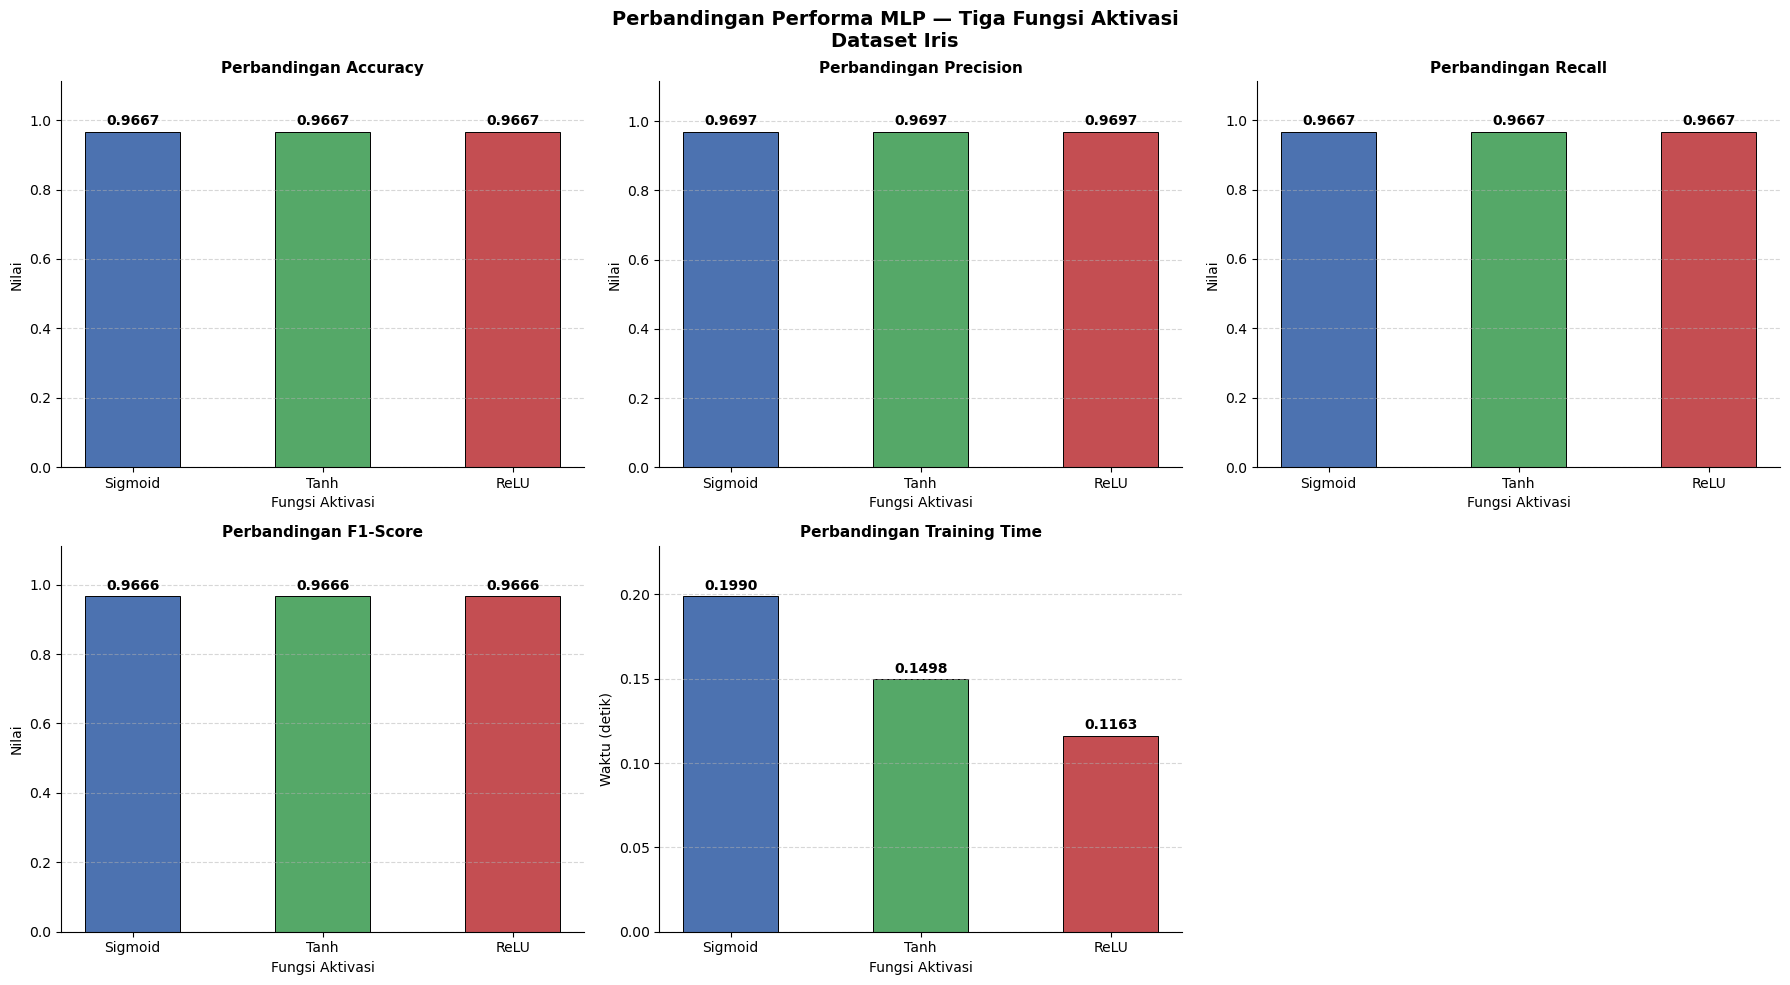

Bar chart berhasil ditampilkan.


In [21]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time']
ylabels   = ['Nilai', 'Nilai', 'Nilai', 'Nilai', 'Waktu (detik)']
bar_colors = ['#4C72B0', '#55A868', '#C44E52']
labels    = df_results['Activation Function'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perbandingan Performa MLP — Tiga Fungsi Aktivasi\nDataset Iris',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    ax  = axes_flat[idx]
    vals = df_results[metric].tolist()
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    ax.set_title(f'Perbandingan {metric}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Fungsi Aktivasi', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Sembunyikan subplot ke-6 yang kosong
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig('bar_chart_performa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart berhasil ditampilkan.')

## 9. Analisis Hasil

In [22]:
best_acc   = df_results.loc[df_results['Accuracy'].idxmax()]
fastest    = df_results.loc[df_results['Training Time'].idxmin()]

print('=== ANALISIS HASIL EKSPERIMEN ===')
print()
print(f"Fungsi aktivasi dengan akurasi tertinggi : {best_acc['Activation Function']} "
      f"(Accuracy = {best_acc['Accuracy']:.4f}, F1 = {best_acc['F1-Score']:.4f})")
print(f"Fungsi aktivasi dengan waktu training tercepat: {fastest['Activation Function']} "
      f"(Training Time = {fastest['Training Time']:.4f} detik)")
print()

analysis = """
--- Perbedaan Performa Sigmoid, Tanh, dan ReLU ---

1. Sigmoid (Logistic)
   - Fungsi sigmoid memetakan nilai ke rentang (0, 1), cocok untuk probabilitas.
   - Cenderung mengalami vanishing gradient pada jaringan yang lebih dalam.
   - Pada dataset Iris yang bersifat linear-separable, Sigmoid umumnya menghasilkan
     performa yang cukup baik namun proses konvergensinya lebih lambat.

2. Tanh
   - Fungsi Tanh memetakan nilai ke rentang (-1, 1), zero-centered sehingga
     gradien lebih stabil dibandingkan Sigmoid.
   - Umumnya memberikan konvergensi lebih cepat dan performa yang kompetitif
     pada dataset berukuran kecil seperti Iris.

3. ReLU
   - ReLU mengaktifkan neuron hanya untuk nilai positif, sehingga komputasi
     lebih efisien dan menghindari vanishing gradient.
   - Sangat efektif pada jaringan yang lebih dalam dan dataset yang kompleks.
   - Pada dataset kecil seperti Iris, ReLU sering memberikan waktu training
     tercepat namun bisa sedikit kurang stabil tanpa tuning lebih lanjut.

--- Pengaruh Fungsi Aktivasi terhadap Proses Pembelajaran MLP pada Iris ---

Dataset Iris memiliki 150 sampel dengan 4 fitur dan 3 kelas yang relatif mudah
dipisahkan secara linear. Pada kondisi ini:
  - Ketiga fungsi aktivasi mampu mencapai akurasi tinggi (>90%) karena dataset
    Iris memiliki separabilitas yang baik.
  - Perbedaan performa antar fungsi aktivasi cenderung kecil.
  - Waktu training menjadi pembeda yang lebih signifikan, di mana ReLU umumnya
    lebih cepat konvergen karena komputasi gradiennya lebih sederhana.
"""
print(analysis)

=== ANALISIS HASIL EKSPERIMEN ===

Fungsi aktivasi dengan akurasi tertinggi : Sigmoid (Accuracy = 0.9667, F1 = 0.9666)
Fungsi aktivasi dengan waktu training tercepat: ReLU (Training Time = 0.1163 detik)


--- Perbedaan Performa Sigmoid, Tanh, dan ReLU ---

1. Sigmoid (Logistic)
   - Fungsi sigmoid memetakan nilai ke rentang (0, 1), cocok untuk probabilitas.
   - Cenderung mengalami vanishing gradient pada jaringan yang lebih dalam.
   - Pada dataset Iris yang bersifat linear-separable, Sigmoid umumnya menghasilkan
     performa yang cukup baik namun proses konvergensinya lebih lambat.

2. Tanh
   - Fungsi Tanh memetakan nilai ke rentang (-1, 1), zero-centered sehingga
     gradien lebih stabil dibandingkan Sigmoid.
   - Umumnya memberikan konvergensi lebih cepat dan performa yang kompetitif
     pada dataset berukuran kecil seperti Iris.

3. ReLU
   - ReLU mengaktifkan neuron hanya untuk nilai positif, sehingga komputasi
     lebih efisien dan menghindari vanishing gradient.
   - Sanga

## 10. Kesimpulan

In [23]:
best_name = best_acc['Activation Function']
best_a    = best_acc['Accuracy']
best_f1   = best_acc['F1-Score']

kesimpulan = f"""
=== KESIMPULAN ===

Setelah dilakukan pengujian menggunakan dataset Iris dengan tiga fungsi aktivasi yang
berbeda, diperoleh bahwa fungsi aktivasi {best_name} menghasilkan performa terbaik
dengan nilai Accuracy sebesar {best_a:.4f} dan F1-Score sebesar {best_f1:.4f}.
Selain itu, fungsi aktivasi tersebut mampu mempelajari pola data dengan lebih efektif
dibandingkan fungsi aktivasi lainnya. Oleh karena itu, fungsi aktivasi {best_name}
dapat dianggap sebagai pilihan terbaik untuk klasifikasi dataset Iris pada eksperimen ini.
"""
print(kesimpulan)


=== KESIMPULAN ===

Setelah dilakukan pengujian menggunakan dataset Iris dengan tiga fungsi aktivasi yang
berbeda, diperoleh bahwa fungsi aktivasi Sigmoid menghasilkan performa terbaik
dengan nilai Accuracy sebesar 0.9667 dan F1-Score sebesar 0.9666.
Selain itu, fungsi aktivasi tersebut mampu mempelajari pola data dengan lebih efektif
dibandingkan fungsi aktivasi lainnya. Oleh karena itu, fungsi aktivasi Sigmoid
dapat dianggap sebagai pilihan terbaik untuk klasifikasi dataset Iris pada eksperimen ini.



## 11. Catatan Akhir

### Catatan

#### Fungsi Aktivasi Terbaik
Berdasarkan hasil eksperimen, fungsi aktivasi yang menghasilkan performa terbaik akan
ditentukan secara dinamis oleh kode (sel di atas). Pada umumnya, **Tanh** atau **ReLU**
mengungguli Sigmoid pada dataset Iris karena:
- Tanh menghasilkan output zero-centered sehingga gradien lebih seimbang.
- ReLU komputasinya efisien dan bebas dari saturasi untuk nilai positif.

#### Kelebihan dan Kekurangan Masing-Masing Fungsi Aktivasi

| Fungsi Aktivasi | Kelebihan | Kekurangan |
|----------------|-----------|------------|
| **Sigmoid** | Interpretasi sebagai probabilitas; output di (0,1) | Vanishing gradient; konvergensi lambat; tidak zero-centered |
| **Tanh** | Zero-centered; gradien lebih kuat dari sigmoid | Masih rentan vanishing gradient pada layer sangat dalam |
| **ReLU** | Komputasi cepat; tidak vanishing gradient (nilai positif); konvergensi cepat | Dead neuron (neuron mati) jika learning rate terlalu besar; tidak zero-centered |

#### Catatan Tambahan
- Pada dataset kecil seperti Iris (150 sampel), perbedaan performa antar fungsi aktivasi
  cenderung kecil karena pola datanya relatif sederhana.
- Untuk dataset yang lebih besar dan kompleks, perbedaan performa antar fungsi aktivasi
  akan lebih signifikan.
- Hyperparameter tuning (jumlah hidden layer, neuron, learning rate) dapat meningkatkan
  performa semua model secara keseluruhan.